In [1]:
from datasets import load_dataset
emotions = load_dataset('emotion')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [2]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [3]:
train_ds = emotions["train"]
train_ds[0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [4]:
len(train_ds)

16000

In [5]:
print(train_ds.features)

{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}


In [6]:
print(train_ds['text'][:5])

['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy']


In [7]:
import pandas as pd
df = pd.DataFrame(train_ds[:])
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [8]:
def label_int2str(label_int):
    return emotions['train'].features['label'].int2str(label_int)

df['label_name'] = df['label'].apply(label_int2str)
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


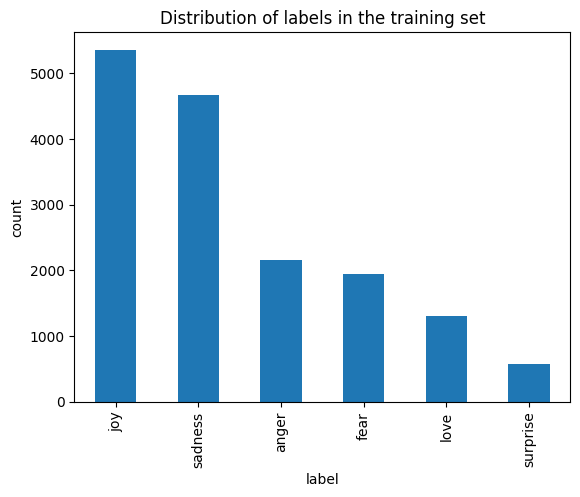

In [9]:
import matplotlib.pyplot as plt
df["label_name"].value_counts().plot(kind="bar")
plt.xlabel("label")
plt.ylabel("count")
plt.title("Distribution of labels in the training set")
plt.show()

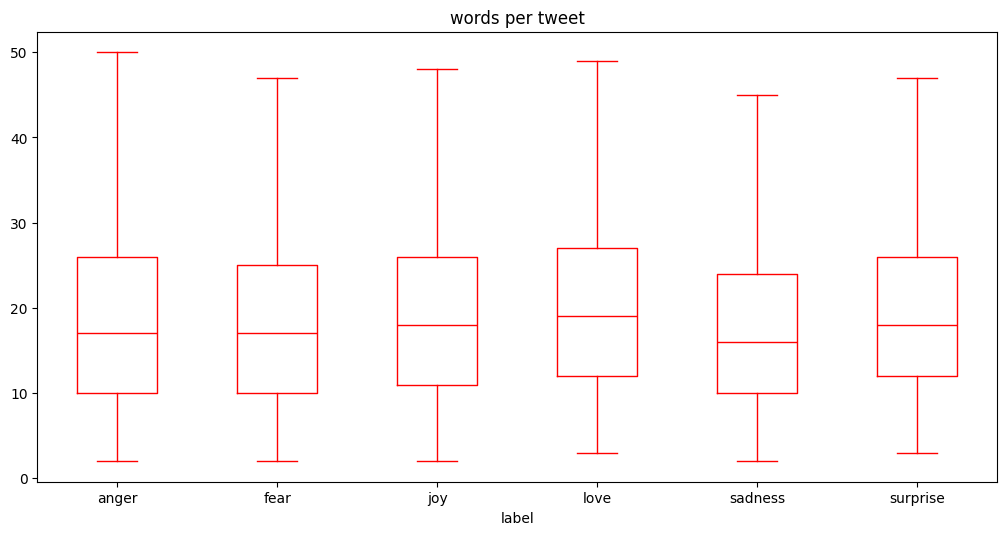

In [10]:
df["words per tweet"] = df["text"].str.split().apply(len)
df.boxplot(column="words per tweet", by="label_name", grid=False, showfliers=False, figsize=(12, 6),color = "red")
plt.suptitle("")
plt.xlabel("label")
plt.show()

## Subword Tokenization

In [11]:
!pip install transformers torch

In [12]:
from transformers import AutoTokenizer
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [13]:
from transformers import DistilBertTokenizer
distilbert_tokenizer = DistilBertTokenizer.from_pretrained(model_ckpt)
tokenizer("Hello, this is a test sentence!")

{'input_ids': [101, 7592, 1010, 2023, 2003, 1037, 3231, 6251, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [14]:
def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

In [15]:
print(tokenize(emotions["train"][:2]))

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


In [16]:
emotions_encoded = emotions.map(tokenize,batched=True, batch_size=None)
print(emotions_encoded["train"].column_names)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


In [18]:
import torch
from transformers import AutoModel
model_ckpt = "distilbert-base-uncased"

model = AutoModel.from_pretrained(model_ckpt)
model

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [19]:
text = "this is a text sentence"
inputs = tokenizer(text, return_tensors="pt")
print(f"inputs tensor : {inputs['input_ids'].size()}")

inputs tensor : torch.Size([1, 7])


In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
inputs = {k:v.to(device) for k,v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)
    print(outputs)

SequenceClassifierOutput(loss=None, logits=tensor([[ 0.3249,  0.7870, -1.1164,  0.2474,  0.3253, -1.3650]],
       device='cuda:0'), hidden_states=None, attentions=None)


In [23]:
outputs.last_hidden_state.size() # [batch_size, sequence_length, hidden_size]

torch.Size([1, 7, 768])

In [62]:
def extract_hidden_state(batch):
    # place model inputs on the GPU
    inputs = {k:v for k,v in batch.items() if k in tokenizer.model_input_names}
    with torch.no_grad():
        last_hidden_state = model(**inputs).last_hidden_state
    return {"hidden_state": last_hidden_state[:,0].numpy()}

Convert the input_ids and attention_mask columns to the "torch"-format

In [28]:
emotions_encoded.set_format("torch", columns=["input_ids", "attention_mask","label"])

In [29]:
emotions_hidden = emotions_encoded.map(extract_hidden_state, batched=True)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [30]:
emotions_hidden["train"].column_names

['text',
 'label',
 'input_ids',
 'token_type_ids',
 'attention_mask',
 'hidden_state']

In [31]:
import numpy as np

x_train = np.array(emotions_hidden["train"]["hidden_state"])
x_valid = np.array(emotions_hidden["validation"]["hidden_state"])
y_train = np.array(emotions_hidden["train"]["label"])
y_valid = np.array(emotions_hidden["validation"]["label"])

x_train.shape, x_valid.shape

((16000, 768), (2000, 768))

In [32]:
!pip install umap-learn

In [33]:
from umap import UMAP
from sklearn.preprocessing import MinMaxScaler

x_scaled = MinMaxScaler().fit_transform(x_train)
mapper = UMAP(n_components=2, metric="cosine").fit(x_scaled)
df_emb = pd.DataFrame(mapper.embedding_, columns=["UMAP1", "UMAP2"])
df_emb["label"] = y_train
df_emb.head()

,UMAP1,UMAP2,label
0,4.270546,3.585752,0
1,-2.962119,4.227735,0
2,5.165936,6.898013,3
3,-2.345017,6.185878,2
4,-3.295628,6.142864,3


/tmp/ipykernel_551/2635292464.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()
/tmp/ipykernel_551/2635292464.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()
/tmp/ipykernel_551/2635292464.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()
/tmp/ipykernel_551/2635292464.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()
/tmp/ipykernel_551/2635292464.py:13: UserWarning: No artists with labels found to put in legend.

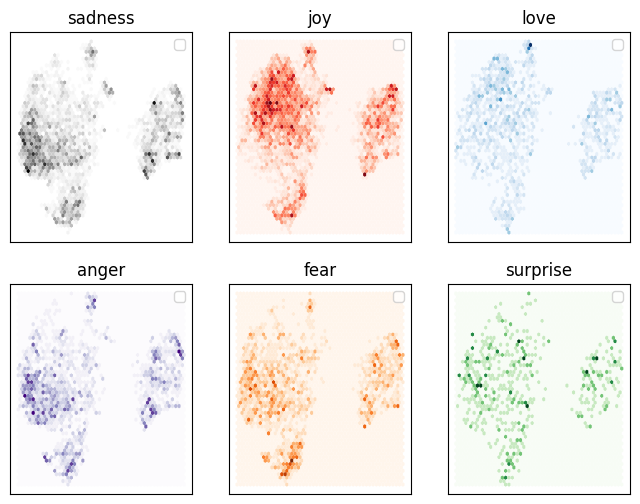

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(8,6))
axes = axes.flatten()
camps = ["Greys", "Reds", "Blues", "Purples", "Oranges", "Greens"]
labels = emotions["train"].features["label"].names

for i, label in enumerate(zip(labels, camps)):
    label_name, camp = label
    df_emb_label = df_emb.query(f"label == {i}")
    axes[i].hexbin(df_emb_label["UMAP1"], df_emb_label["UMAP2"], gridsize=50, cmap=camp, linewidths=(0,))
    axes[i].set_title(label_name)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].legend()

In [35]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(max_iter=3000)
lr_clf.fit(x_train, y_train)
lr_clf.score(x_valid, y_valid)

0.6335

In [36]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(x_train, y_train)
dummy_clf.score(x_valid, y_valid)

0.352

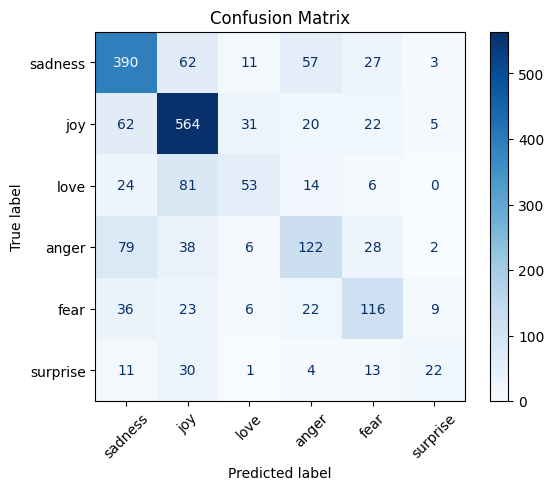

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()

y_pred = lr_clf.predict(x_valid)
plot_confusion_matrix(y_valid, y_pred, labels)

## Fine-Tuning Transformers

In [65]:
from transformers import AutoModelForSequenceClassification
num_labels = 6
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = (AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=num_labels).to(device))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [40]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1}

In [42]:
from huggingface_hub import login
login()

In [45]:
from transformers import Trainer, TrainingArguments

batch_size = 64
logging_steps = len(emotions_encoded["train"])
model_name = f"{model_ckpt}.finetuned-emotion"
training_args = TrainingArguments(output_dir=model_ckpt,
                                  num_train_epochs = 2,
                                  learning_rate = 2e-5,
                                  per_device_train_batch_size = batch_size,
                                  per_device_eval_batch_size = batch_size,
                                  weight_decay = 0.01,
                                  disable_tqdm = False,
                                  logging_steps = logging_steps,
                                  push_to_hub = True,
                                  log_level = "error")

In [47]:
from transformers import Trainer

trainer = Trainer(model=model, args = training_args,
                  compute_metrics=compute_metrics,
                  train_dataset = emotions_encoded["train"],
                  eval_dataset = emotions_encoded["validation"])
trainer.train()

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=0.5374429321289063, metrics={'train_runtime': 236.1733, 'train_samples_per_second': 135.494, 'train_steps_per_second': 2.117, 'total_flos': 720342861696000.0, 'train_loss': 0.5374429321289063, 'epoch': 2.0})

In [48]:
preds_output = trainer.predict(emotions_encoded["validation"])

In [49]:
preds_output.metrics

{'test_loss': 0.21882253885269165,
 'test_accuracy': 0.926,
 'test_f1': 0.9258844814458328,
 'test_runtime': 3.9216,
 'test_samples_per_second': 509.999,
 'test_steps_per_second': 8.16}

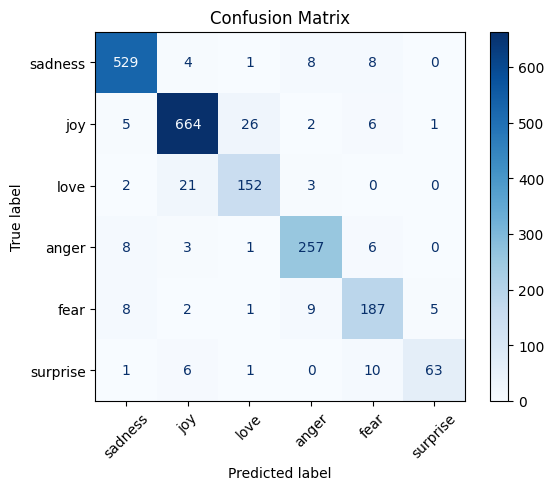

In [50]:
y_preds = np.argmax(preds_output.predictions, axis=1)
plot_confusion_matrix(emotions_encoded["validation"]["label"], y_preds, labels)

## Error Analysis

In [74]:
from torch.nn.functional import cross_entropy

def forward_pass_with_label(batch):
    # Ensure all relevant inputs are on the same device as the model
    inputs = {k:v.to(device) for k,v in batch.items() if k in tokenizer.model_input_names}
    with torch.no_grad():
        output = model(**inputs)
        pred_label = torch.argmax(output.logits, axis=1)
        # Calculate loss per sample in the batch by setting reduction='none'
        loss_per_sample = cross_entropy(output.logits, batch["label"].to(device), reduction='none')

    # Return lists of values for each new column, matching the batch size
    return {"loss": loss_per_sample.cpu().numpy().tolist(), "predicted_label": pred_label.cpu().numpy().tolist()}

In [75]:
emotions_encoded.set_format("torch", columns=["input_ids", "attention_mask", "label"])
emotions_encoded["validation"] = emotions_encoded["validation"].map(forward_pass_with_label, batched=True, batch_size=16)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [77]:
emotions_encoded.set_format("pandas")
col = ["text", "label", "predicted_label", "loss"]
df_test = emotions_encoded["validation"][:][col]
df_test.head(10)

,text,label,predicted_label,loss
0,im feeling quite sad and sorry for myself but ...,0,0,0.017066
1,i feel like i am still looking at a blank canv...,0,0,0.021071
2,i feel like a faithful servant,2,2,0.539039
3,i am just feeling cranky and blue,3,3,0.036121
4,i can have for a treat or if i am feeling festive,1,1,0.022646
5,i start to feel more appreciative of what god ...,1,1,0.028832
6,i am feeling more confident that we will be ab...,1,1,0.029641
7,i feel incredibly lucky just to be able to tal...,1,1,0.021254
8,i feel less keen about the army every day,1,1,0.024663
9,i feel dirty and ashamed for saying that,0,0,0.017998


In [78]:
trainer.push_to_hub(commit_message="Training completed!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...uncased/training_args.bin: 100%|##########| 5.14kB / 5.14kB            

  ...uncased/model.safetensors:   9%|8         | 23.9MB /  268MB            

CommitInfo(commit_url='https://huggingface.co/mishbahulal/distilbert-base-uncased/commit/98ee71529c9f9090fe5fbf08d40c0f402e3f5035', commit_message='Training completed!', commit_description='', oid='98ee71529c9f9090fe5fbf08d40c0f402e3f5035', pr_url=None, repo_url=RepoUrl('https://huggingface.co/mishbahulal/distilbert-base-uncased', endpoint='https://huggingface.co', repo_type='model', repo_id='mishbahulal/distilbert-base-uncased'), pr_revision=None, pr_num=None)